# Training Data Generator — WarmStartPlanner

## Goal

Each data point is a tuple **(environment, start, goal → reference trajectory)**:

| Field | Shape | Meaning |
|---|---|---|
| `sdf` | `[1, H, W]` | Signed Distance Field of the environment |
| `q_start` | `[dof]` | Collision-free start joint angles |
| `q_goal` | `[dof]` | Collision-free goal joint angles |
| `q_traj` | `[T, dof]` | CHOMP reference trajectory (label) |
| `obstacles` | `[max_obs, 3]` | Obstacle positions and radii `(x, y, r)`, zero-padded |
| `n_obstacles` | scalar | Actual number of obstacles in this environment |

---

## Concept 1 — Meaningful Environments

**Circular obstacles within the robot workspace** (`sample_circular_obstacles`):
- Obstacles placed using **polar coordinates** (`r ≤ workspace_radius`) so they always
  lie within the robot's reachable area — not somewhere irrelevant outside it
- **Minimum separation** between obstacles prevents completely blocked environments
  where no feasible path exists
- Random count `[n_min, n_max]` and radii `[r_min, r_max]` for diversity

---

## Concept 2 — Meaningful Start/Goal Pairs

**Two-stage filter** (`sample_valid_pair`):
1. **Collision-free endpoints**: both `q_start` and `q_goal` must be reachable without collision
2. **Non-trivial**: at least one point along the straight joint-space line is in collision

Why the second filter matters: if the straight line is already collision-free, the task is trivial —
the network would only learn to output straight-line interpolations and never learn to navigate
around obstacles.

---

## Concept 3 — Data Combination

```
N_envs environments × pairs_per_env pairs per environment
         ↓
  CHOMP computes reference trajectory (with sinusoidal restarts)
         ↓
  Success filter: collision rate < success_threshold
         ↓
  Dataset = { sdf, q_start, q_goal, q_traj, obstacles, n_obstacles, metadata }
```

**Why N_envs × pairs_per_env?**
Multiple pairs per environment: the network sees the same environment from different start/goal
perspectives and learns to actually use the encoder output (not just interpolate start/goal).
Too many pairs per environment → risk of overfitting to few environments.
Rule of thumb: 3–10 pairs per environment.


In [29]:
# ---- Setup ----
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo
from simplearm.geom import Obstacles
from simplearm.viz import RobotViewer

from data import (
    build_sdf_tensor,
    sample_circular_obstacles,
    visualize_environment,
    is_collision_free,
    straight_line_blocked,
    sample_valid_pair,
    compute_reference_trajectory,
    generate_dataset,
)
from losses import compute_smoothness_cost
from utils import get_world_spheres_torch, query_sdf_differentiable

# ── Robot and grid parameters ─────────────────────────────────────────────────
LINKLENGTHS  = [0.3, 0.4, 0.3]
SPHERE_RAD   = 0.08
GRID_LENGTH  = 2.5
N_VOX        = 128
T            = 50   # trajectory length (timesteps)
C            = 10   # B-spline waypoints — must match WarmStartPlanner

robot            = RobotInfo.from_linklengths(LINKLENGTHS, sphere_rad=SPHERE_RAD)
DOF              = robot.n_dof
WORKSPACE_RADIUS = sum(LINKLENGTHS)

# joint limits
Q_MIN = np.array([-np.pi, -np.pi*0.9, -np.pi*0.9])
Q_MAX = np.array([ np.pi,  np.pi*0.9,  np.pi*0.9])

print(robot)
print(f"Workspace radius: {WORKSPACE_RADIUS:.2f} m")
print(f"Joint limits:     Q_MIN={np.round(Q_MIN, 2)}  Q_MAX={np.round(Q_MAX, 2)}")

A Robot with the following properties:
  Link Lengths: [0.3 0.4 0.3]
  Number of Spheres: 10
  Mass per Link: [1. 1. 1.]
  Inertia per Link: [0.1 0.1 0.1]
  Number of ignore sphere pairs: 18
Workspace radius: 1.00 m
Joint limits:     Q_MIN=[-3.14 -2.83 -2.83]  Q_MAX=[3.14 2.83 2.83]


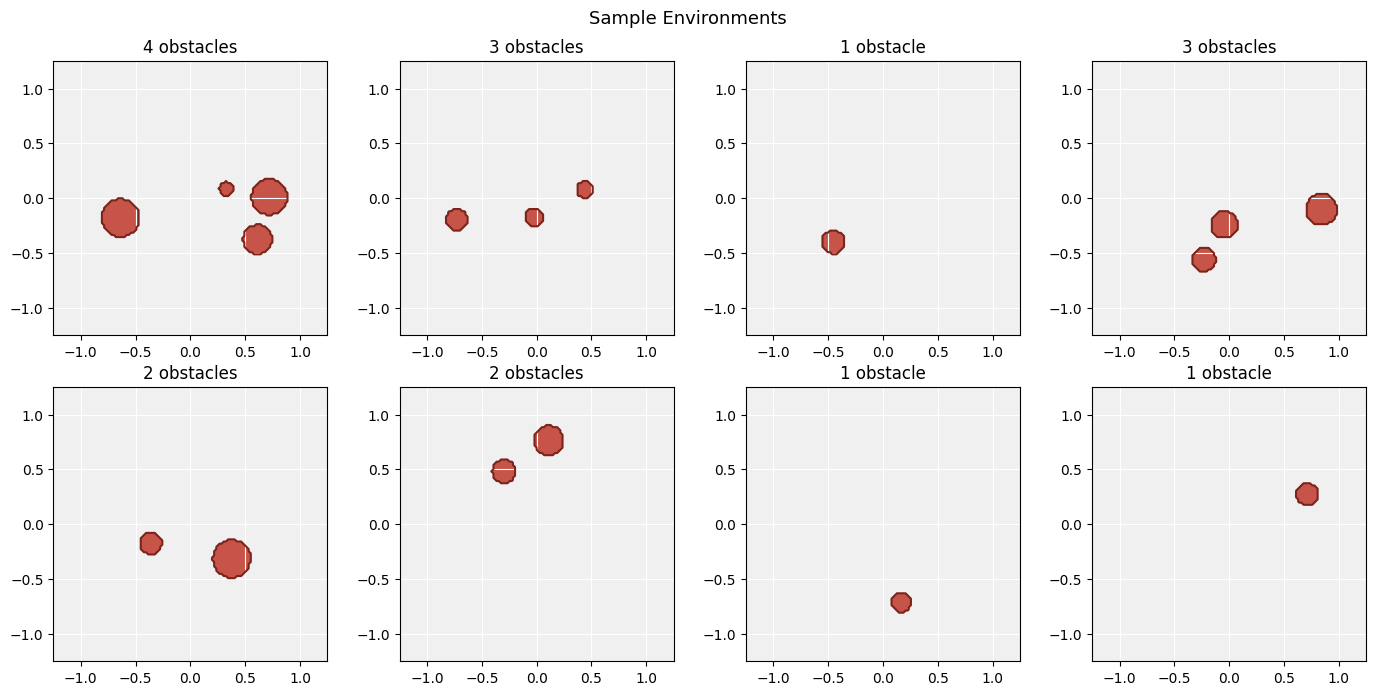

In [30]:
# ---- Preview sample environments ----
rng_preview = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.flat:
    n_obs = rng_preview.integers(1, 5)
    obs   = sample_circular_obstacles(
        n_obstacles=n_obs, workspace_radius=WORKSPACE_RADIUS, rng=rng_preview
    )
    sdf = build_sdf_tensor(obs, GRID_LENGTH, N_VOX)
    visualize_environment(sdf, GRID_LENGTH, ax=ax)
    ax.set_title(f"{n_obs} obstacle{'s' if n_obs > 1 else ''}")
plt.suptitle("Sample Environments", fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# ---- Sanity check: pair sampling ----
rng_check = np.random.default_rng(1)
obs_check = sample_circular_obstacles(n_obstacles=3, workspace_radius=WORKSPACE_RADIUS, rng=rng_check)
sdf_check = build_sdf_tensor(obs_check, GRID_LENGTH, N_VOX)

result = sample_valid_pair(
    sdf_check, robot, Q_MIN, Q_MAX, GRID_LENGTH,
    require_nontrivial=True, rng=rng_check,
)

if result:
    q_s, q_g = result
    print("Valid pair found:")
    print(f"  q_start = {np.round(q_s, 3)}")
    print(f"  q_goal  = {np.round(q_g, 3)}")
    print(f"  Start collision-free:  {is_collision_free(q_s, sdf_check, robot, GRID_LENGTH)}")
    print(f"  Goal  collision-free:  {is_collision_free(q_g, sdf_check, robot, GRID_LENGTH)}")
    print(f"  Straight line blocked: {straight_line_blocked(q_s, q_g, sdf_check, robot, GRID_LENGTH)}")
else:
    print("No valid pair found within max_tries.")

Valid pair found:
  q_start = [-2.968  1.434  0.216]
  q_goal  = [-1.07   1.631 -1.113]
  Start collision-free:  True
  Goal  collision-free:  True
  Straight line blocked: True


In [48]:
# ---- Generate dataset ----
# Adjust parameters here and run this cell to (re-)generate the training data.
dataset = generate_dataset(
    N_envs            = 10,
    pairs_per_env     = 5,
    robot             = robot,
    sphere_rad        = SPHERE_RAD,
    q_min             = Q_MIN,
    q_max             = Q_MAX,
    n_obstacles_range = (1, 3),
    r_range           = (0.06, 0.18),
    workspace_radius  = WORKSPACE_RADIUS,
    require_nontrivial= True,
    T                 = T,
    C                 = C,
    chomp_n_restarts  = 3,
    chomp_n_iter      = 500,
    chomp_w_jl        = 50.0,
    success_threshold = 0.01,
    grid_length       = GRID_LENGTH,
    n_vox             = N_VOX,
    seed              = 42,
    save_path         = "data/training_dataset.pt",
)

Generating dataset:   0%|          | 0/10 [00:00<?, ?it/s]


────────────────────────────────────────────────
  Attempts:           50
  No valid pair:      1
  CHOMP failed:       17
  Successful samples: 32  (64.0%)
────────────────────────────────────────────────
  Saved: data/training_dataset.pt  (2.1 MB)


Dataset: 32 samples
  sdf          (32, 1, 128, 128)
  q_start      (32, 3)
  q_goal       (32, 3)
  q_traj       (32, 50, 3)
  obstacles    (32, 3, 3)
  n_obstacles  (32,)

Metadata: {'N': 32, 'T': 50, 'C': 10, 'grid_length': 2.5, 'n_vox': 128, 'dof': 3, 'linklengths': [0.3, 0.4, 0.3], 'sphere_rad': 0.08, 'q_min': [-3.141592653589793, -2.827433388230814, -2.827433388230814], 'q_max': [3.141592653589793, 2.827433388230814, 2.827433388230814]}


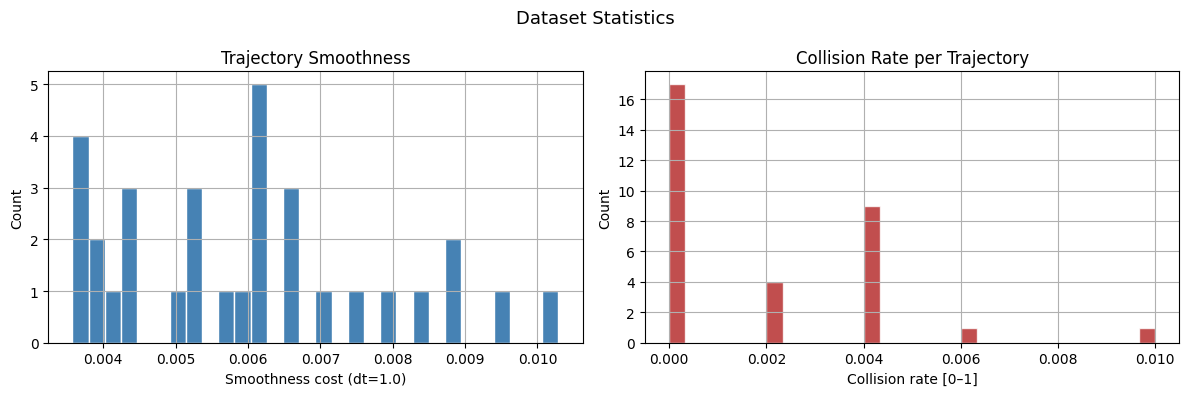

Collision:  mean=0.002  max=0.010
Smoothness: mean=0.0060  max=0.0103


In [51]:
# ---- Dataset statistics ----
if not dataset:
    print("No dataset available — run the generation cell first.")
else:
    N   = dataset["metadata"]["N"]
    dof = dataset["metadata"]["dof"]

    print(f"Dataset: {N} samples")
    for key in ("sdf", "q_start", "q_goal", "q_traj", "obstacles", "n_obstacles"):
        print(f"  {key:<12} {tuple(dataset[key].shape)}")
    print(f"\nMetadata: {dataset['metadata']}")

    smoothness = [
        compute_smoothness_cost(dataset["q_traj"][i].unsqueeze(0), dt=1.0).item()
        for i in range(min(N, 500))
    ]
    coll_rates = []
    for i in range(min(N, 100)):
        q_t   = dataset["q_traj"][i]
        sdf_i = dataset["sdf"][i, 0]
        sp    = get_world_spheres_torch(q_t, robot)
        dist  = query_sdf_differentiable(sdf_i, sp.reshape(-1, 2), GRID_LENGTH)
        coll_rates.append((dist < 0).float().mean().item())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(smoothness, bins=30, color="steelblue", edgecolor="white")
    axes[0].set(xlabel="Smoothness cost (dt=1.0)", ylabel="Count", title="Trajectory Smoothness")
    axes[0].grid(True)

    axes[1].hist(coll_rates, bins=30, color="firebrick", edgecolor="white", alpha=0.8)
    axes[1].set(xlabel="Collision rate [0–1]", ylabel="Count", title="Collision Rate per Trajectory")
    axes[1].grid(True)

    plt.suptitle("Dataset Statistics", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"Collision:  mean={np.mean(coll_rates):.3f}  max={np.max(coll_rates):.3f}")
    print(f"Smoothness: mean={np.mean(smoothness):.4f}  max={np.max(smoothness):.4f}")

In [56]:
# ---- Visualize a random sample from the dataset ----
dataset = torch.load("data/training_dataset.pt", weights_only=False)
N_ds    = dataset["metadata"]["N"]

robot_ds = RobotInfo.from_linklengths(
    dataset["metadata"]["linklengths"],
    sphere_rad=dataset["metadata"]["sphere_rad"],
)

SAMPLE_IDX = None  # set to an integer to pin a specific sample
if SAMPLE_IDX is None:
    SAMPLE_IDX = torch.randint(0, N_ds, (1,)).item()

q_start_np    = dataset["q_start"][SAMPLE_IDX].numpy()
q_goal_np     = dataset["q_goal"][SAMPLE_IDX].numpy()
q_traj_ref_np = dataset["q_traj"][SAMPLE_IDX].numpy()

n_obs    = dataset["n_obstacles"][SAMPLE_IDX].item()
obs_data = dataset["obstacles"][SAMPLE_IDX]
obstacles_sample = Obstacles(
    x=obs_data[:n_obs, 0].numpy(),
    y=obs_data[:n_obs, 1].numpy(),
    r=obs_data[:n_obs, 2].numpy(),
)

print(f"Sample {SAMPLE_IDX} / {N_ds}")
print(f"  q_start:   {np.round(q_start_np, 3)}")
print(f"  q_goal:    {np.round(q_goal_np, 3)}")
print(f"  obstacles: {n_obs}")

viz = RobotViewer(q_traj_ref_np, robot_ds, obstacles=obstacles_sample)
viz.plot()

Sample 8 / 32
  q_start:   [ 1.621 -0.357 -1.647]
  q_goal:    [-2.852 -0.211  1.78 ]
  obstacles: 1
⠙ Plotting robot... (0:00:00.49) 